<a href="https://colab.research.google.com/github/JanviSingh04/Covid-19-detection-using-lung-x-ray/blob/main/multi_candidate_interview_evaluation_system_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install openai-whisper
!pip install librosa
!pip install nltk
!pip install textblob
!pip install pandas
import os
import whisper
import librosa
import pandas as pd
import nltk

from textblob import TextBlob

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 30.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 6.4 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=107aa9e1022d8168c69f83fda0395b88ac3eca295a862c2829c1326ce9a27334
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
model = whisper.load_model("base")

100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 95.4MiB/s]


In [ ]:
folder_path = "/content/drive/MyDrive/Interview_Audios"

In [ ]:
files = os.listdir(folder_path)

print(files)

['candidate1.mp3.mp3', 'candidate3.mp3.mp3', 'candidate2.mp3.mp3']


In [ ]:
results = []

In [ ]:
for file_name in os.listdir(folder_path):

    # Process only MP3 files
    if file_name.endswith(".mp3"):

        print("\n============================")
        print("Processing:", file_name)

        # Full audio path
        audio_path = os.path.join(folder_path, file_name)

        # -----------------------------------
        # SPEECH TO TEXT
        # -----------------------------------
        result = model.transcribe(audio_path)

        text = result["text"]

        print("\nTranscript Preview:")
        print(text[:300])

        # -----------------------------------
        # WORD COUNT
        # -----------------------------------
        words = text.split()

        total_words = len(words)

        # -----------------------------------
        # AUDIO DURATION
        # -----------------------------------
        y, sr = librosa.load(audio_path)

        duration = librosa.get_duration(y=y, sr=sr)

        minutes = duration / 60

        # -----------------------------------
        # WORDS PER MINUTE
        # -----------------------------------
        wpm = total_words / minutes

        # -----------------------------------
        # FILLER WORD DETECTION
        # -----------------------------------
        filler_words = [
            "um",
            "uh",
            "like",
            "actually",
            "basically",
            "you know"
        ]

        filler_count = 0

        for word in words:
            if word.lower() in filler_words:
                filler_count += 1

        # -----------------------------------
        # FLUENCY SCORE
        # -----------------------------------
        fluency_score = max(0, 100 - (filler_count * 2))

        # -----------------------------------
        # SENTIMENT ANALYSIS
        # -----------------------------------
        analysis = TextBlob(text)

        polarity = analysis.sentiment.polarity

        sentiment_score = (polarity + 1) * 50

        # -----------------------------------
        # SPEED SCORE
        # -----------------------------------
        if 110 <= wpm <= 160:
            speed_score = 90

        elif 90 <= wpm < 110:
            speed_score = 70

        elif 160 < wpm <= 190:
            speed_score = 65

        else:
            speed_score = 50

        # -----------------------------------
        # TEMPORARY EMOTION SCORE
        # -----------------------------------
        emotion_score = 80

        # -----------------------------------
        # CONFIDENCE SCORE
        # -----------------------------------
        confidence_score = (
            0.3 * emotion_score +
            0.3 * fluency_score +
            0.2 * speed_score +
            0.2 * sentiment_score
        )

        # -----------------------------------
        # NLP SCORE
        # -----------------------------------
        nlp_score = (
            0.5 * fluency_score +
            0.5 * sentiment_score
        )

        # -----------------------------------
        # FINAL INTERVIEW SCORE
        # -----------------------------------
        final_score = (
            0.35 * nlp_score +
            0.25 * emotion_score +
            0.20 * confidence_score +
            0.20 * speed_score
        )

        # -----------------------------------
        # STORE RESULTS
        # -----------------------------------
        results.append({

            "Candidate": file_name,

            "Words": total_words,

            "WPM": round(wpm, 2),

            "Filler Words": filler_count,

            "Fluency": round(fluency_score, 2),

            "Sentiment": round(sentiment_score, 2),

            "Confidence": round(confidence_score, 2),

            "Final Score": round(final_score, 2)

        })

        print("\nFinal Score:", round(final_score, 2))


Processing: candidate1.mp3.mp3


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Transcript Preview:
 All right, let's get started with the interview. Hey, Aaron, thanks for joining me today. I'm Alex, and I'll be conducting your interview. I'm excited to get started. Can you tell me a little bit about yourself? Hey, Alex, it's nice to meet you. My name's Aaron. I studied computer science at Brown 

Final Score: 80.03

Processing: candidate3.mp3.mp3


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Transcript Preview:
 Hey Paul, I'm Alex and AI Recruiter. You're applying for a role at OpenAI as a research engineer. I'm excited to learn more about you. To get us started here, can you tell me a bit about yourself and what motivated you to apply to this position? Uh, yeah, hey Alex, very excited about this position.

Final Score: 80.7

Processing: candidate2.mp3.mp3


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



Transcript Preview:
 I hope the connection is working well on your end. Can you hear me clearly? I can hear you, and thank you for asking. Can you hear me? Yes, I can hear you perfectly. Well, you know, to be honest, I'm not feeling very well right now. Can we maybe move this interview to some later time? I'm sorry to 

Final Score: 83.85


In [ ]:
df = pd.DataFrame(results)

df

,Candidate,Words,WPM,Filler Words,Fluency,Sentiment,Confidence,Final Score
0,candidate1.mp3.mp3,800,123.50,5,90,58.07,80.61,80.03
1,candidate3.mp3.mp3,731,159.66,7,86,65.52,80.90,80.70
2,candidate2.mp3.mp3,123,144.80,0,100,64.90,84.98,83.85


In [ ]:
df = df.sort_values(
    by="Final Score",
    ascending=False
)

df

,Candidate,Words,WPM,Filler Words,Fluency,Sentiment,Confidence,Final Score
2,candidate2.mp3.mp3,123,144.80,0,100,64.90,84.98,83.85
1,candidate3.mp3.mp3,731,159.66,7,86,65.52,80.90,80.70
0,candidate1.mp3.mp3,800,123.50,5,90,58.07,80.61,80.03


In [ ]:
best_candidate = df.iloc[0]

print("===== BEST CANDIDATE =====")

print(best_candidate)

===== BEST CANDIDATE =====
Candidate       candidate2.mp3.mp3
Words                          123
WPM                          144.8
Filler Words                     0
Fluency                        100
Sentiment                     64.9
Confidence                   84.98
Final Score                  83.85
Name: 2, dtype: object


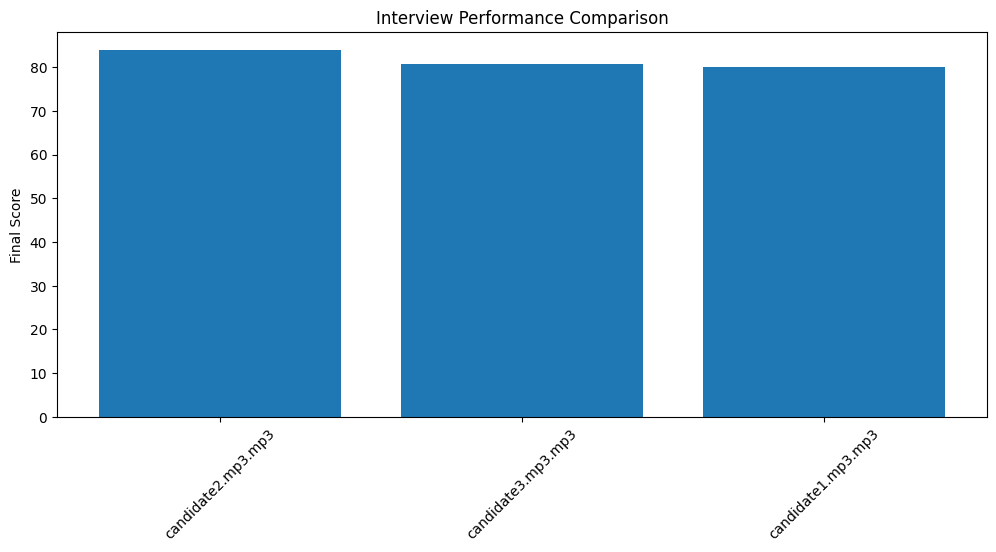

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    df["Candidate"],
    df["Final Score"]
)

plt.title("Interview Performance Comparison")

plt.ylabel("Final Score")

plt.xticks(rotation=45)

plt.show()

In [ ]:
output_path = "/content/drive/MyDrive/interview_results.csv"

df.to_csv(output_path, index=False)

print("Results saved successfully")

Results saved successfully
